In [1]:
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.datasets import load_breast_cancer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Part A

(rows, columns)
(150, 4)
Feature Names: 
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Names: 
['setosa' 'versicolor' 'virginica']
First five rows: 
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


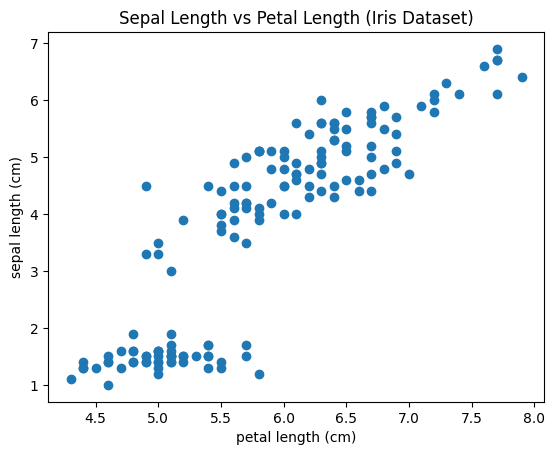

In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
print("(rows, columns)")
print(df.shape)
print("Feature Names: ")
print(iris.feature_names)
print("Target Names: ")
print(iris.target_names)
print("First five rows: ")
print(df.head(5))

plt.scatter(df["sepal length (cm)"],df["petal length (cm)"])
plt.title("Sepal Length vs Petal Length (Iris Dataset)")
plt.xlabel("petal length (cm)")
plt.ylabel("sepal length (cm)")
plt.show()

# Part B

In [3]:
# declaring X (Features) and y (Target)
y = iris.target
X = iris.data
# splitting the data into training (80%) and testing data (20%).
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)
# instansiating the model (KNN)
knn_classifier = KNeighborsClassifier(n_neighbors=3)
# training the model
knn_classifier.fit(X_train,y_train)
# printing the accuracy of the model by comparing it with the test data.
print(knn_classifier.score(X_test,y_test))

1.0


# Part C


In [4]:
wine =  load_wine()
df = pd.DataFrame(wine.data,columns=wine.feature_names)
X = wine.data
y = wine.target

X_train,X_test,y_train,y_test= train_test_split(X,y, test_size=0.2, stratify=y)

l_regression = LogisticRegression()
l_regression1 =LogisticRegression()
l_regression.fit(X_train,y_train)

print(f"without scaling: {l_regression.score(X_test,y_test)}")

scaler = StandardScaler()
X_train_standard = scaler.fit_transform(X_train)
X_test_standard = scaler.transform(X_test)
l_regression1.fit(X_train_standard,y_train)
print(f"with scaling: {l_regression1.score(X_test_standard,y_test)}")


without scaling: 0.9722222222222222
with scaling: 0.9722222222222222


c:\Users\nn\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Scaling had a positive impact on the accuracy of the model. Without scaling, features with larger numeric values may dominate the optimization and that is why the accuracy is comparatively lower without scaling the features data.
when we standarized the feature data, all columns were contributing same towards training the model and that is why the accuracy is higher in this case. 

# Part D

In [5]:
cancer = load_breast_cancer()

X_train,X_test,y_train,y_test = train_test_split(cancer.data,cancer.target,test_size=0.2, stratify=cancer.target)

# building a pipeline which helps  organizing the code and to avoid extra steps.
pipeline = Pipeline([
    ('scaler' , StandardScaler()),
    ('regression', LogisticRegression(max_iter=1000, solver='lbfgs'))
    ])
pipeline.fit(X_train,y_train)
print(f"Final test accuracy: {pipeline.score(X_test,y_test,)}")

Final test accuracy: 0.9736842105263158


# Part E


In [6]:
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

param_grid = {'n_neighbors': [1,3,5,7,9]}

# GridSearchCV with 5-fold cross validation
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV score:", grid.best_score_)

# Evaluate best model on test set
print("Test set accuracy:", grid.best_estimator_.score(X_test, y_test))

Best parameters: {'n_neighbors': 5}
Best CV score: 0.975
Test set accuracy: 1.0


Cross-validation is a technique by which we can evaluate the best performing model by checking the diffrent combinations of data used for training.